#**Bootstrapping**

The Iris data set is one of the popular data sets used to evaluate classification tasks.

This data set contains 150 observations of iris flowers, where each observation contains the features such as sepal length, sepal width, petal length, and petal width.

The target variable is the species of the iris plant.

The Iris data set is widely used in machine learning algorithms to evaluate the performance of different models and is also used as an example to demonstrate the concept of decision tree classifiers.

The code implements a bootstrapping technique for a machine learning model using the DecisionTreeClassifier from the sci-kit-learn library.

The first few lines load the Iris dataset and extract the feature data (X) and target data (y) from it.

The bootstrap function takes in the feature data (X), target data (y), and the number of samples (n_samples) to use in bootstrapping.

The function returns a list of trained models and a pandas data frame with precision, recall, F1 score, and the indices used for bootstrapping.

The bootstrapping process is done in a for loop.

For each iteration, the function uses the **np.random.choice** method to randomly select a sample of the feature data (X) and target data (y).

The sample data is then split into training and testing sets using the train_test_split method. The DecisionTreeClassifier is trained on the training data and then used to make predictions on the testing data.

The precision, recall, and F1 scores are calculated using the metrics.precision_score, metrics.recall_score, and metrics.f1_score methods from the sci-kit-learn library.  These scores are then added to a list for each iteration.

Finally, the results are saved to a pandas data frame with columns for precision, recall, F1 score, the trained models, and the indices used for bootstrapping. The data frame is then returned by the function.

In [1]:
from sklearn import metrics
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

# Load the iris dataset
iris = load_iris()
X, y = iris.data, iris.target


def bootstrap(X, y, n_samples=2000):
    models = []
    precision = []
    recall = []
    f1 = []
    indices_x = []
    indices_y = []

    for i in range(n_samples):
        index_x = np.random.choice(X.shape[0], size=X.shape[0], replace=True)
        indices_x.append(index_x)
        X_sample = X[index_x, :]

        index_y = np.random.choice(y.shape[0], size=y.shape[0], replace=True)
        indices_y.append(index_y)
        y_sample = y[index_y]

        X_train, X_test, y_train, y_test = train_test_split(
            X_sample, y_sample, test_size=0.2, random_state=42
        )

        model = DecisionTreeClassifier().fit(X_train, y_train)
        models.append(model)

        y_pred = model.predict(X_test)
        precision.append(
            metrics.precision_score(y_test, y_pred, average="macro")
        )
        recall.append(metrics.recall_score(y_test, y_pred, average="macro"))
        f1.append(metrics.f1_score(y_test, y_pred, average="macro"))
    # Save the results to a Pandas dataframe
    pred_df = pd.DataFrame(
        {
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Models": models,
            "Indices_X": indices_x,
            "Indices_Y": indices_y,
        }
    )
    # Return the models and the dataframe
    return models, pred_df # Added return statement to return the models and pred_df

In [2]:
models, pred_df = bootstrap(X, y)

Show the results of the data frame that the function creates.



In [3]:
pred_df.head()


,Precision,Recall,F1,Models,Indices_X,Indices_Y
0,0.432997,0.452778,0.437002,DecisionTreeClassifier(),"[65, 89, 141, 25, 118, 104, 67, 67, 78, 23, 38...","[47, 13, 134, 33, 24, 68, 128, 105, 68, 88, 44..."
1,0.488889,0.482418,0.471691,DecisionTreeClassifier(),"[41, 98, 90, 139, 87, 46, 48, 51, 130, 92, 43,...","[87, 137, 146, 0, 67, 20, 112, 140, 59, 9, 139..."
2,0.325397,0.325589,0.321930,DecisionTreeClassifier(),"[147, 108, 18, 89, 0, 19, 55, 119, 144, 27, 35...","[87, 38, 143, 49, 141, 97, 12, 70, 94, 1, 122,..."
3,0.317157,0.308858,0.266294,DecisionTreeClassifier(),"[53, 29, 35, 18, 43, 147, 80, 19, 18, 106, 53,...","[70, 50, 124, 38, 17, 24, 132, 117, 140, 50, 5..."
4,0.448718,0.416667,0.426667,DecisionTreeClassifier(),"[14, 1, 136, 146, 37, 105, 13, 33, 109, 147, 1...","[16, 15, 32, 66, 2, 2, 23, 136, 116, 121, 64, ..."


Now add the index column as the model number, and sort the values by precision.





In [4]:
pred_df['Model Number'] = pred_df.index
pred_df.sort_values(by= "Precision", ascending = False).head(5)



,Precision,Recall,F1,Models,Indices_X,Indices_Y,Model Number
1544,0.726852,0.638889,0.626984,DecisionTreeClassifier(),"[105, 104, 55, 98, 62, 103, 91, 37, 129, 67, 7...","[137, 147, 8, 106, 113, 39, 107, 95, 25, 105, ...",1544
1097,0.621032,0.632576,0.612892,DecisionTreeClassifier(),"[73, 21, 131, 120, 32, 74, 105, 20, 88, 145, 3...","[128, 50, 17, 45, 147, 82, 50, 19, 131, 138, 2...",1097
1886,0.617677,0.556566,0.552634,DecisionTreeClassifier(),"[3, 104, 121, 3, 131, 79, 93, 84, 67, 55, 11, ...","[30, 73, 62, 93, 34, 45, 11, 30, 32, 144, 149,...",1886
224,0.616987,0.430640,0.388384,DecisionTreeClassifier(),"[11, 71, 136, 134, 4, 33, 90, 62, 96, 15, 108,...","[57, 145, 115, 27, 27, 43, 83, 87, 109, 48, 8,...",224
1366,0.604396,0.479798,0.461698,DecisionTreeClassifier(),"[81, 13, 57, 60, 88, 38, 56, 16, 57, 20, 20, 4...","[112, 36, 18, 8, 134, 15, 98, 138, 136, 134, 1...",1366


The code below creates 3 bar graphs to show the performance of bootstrapped models.

The performance of the models is measured by the precision, recall, and F1 scores. So, we will create a data frame called pred_df. This data frame stores the scores of the models.

The code creates a figure with 3 subplots.

The first subplot (ax2) is a bar graph that shows the precision scores of the top 5 models.

The x-axis shows the precision score, and the y-axis shows the model's index. For each bar, the value is displayed in the center of these 3 figures. The title of this graph is "Precision".

The second subplot (ax3) is a bar graph that shows the recall scores of the top 5 models. The x-axis shows the recall score, and the y-axis shows the model's index. The title of this graph is "Recall".

The third subplot (ax4) is a bar graph that shows the F1 scores of the top 5 models. The x-axis shows the F1 score, and the y-axis shows the model's index. The title of this graph is "F1".

The overall title of the figure is "Bootstrapped Model Performance Metrics". We will display these images by using plt.show().

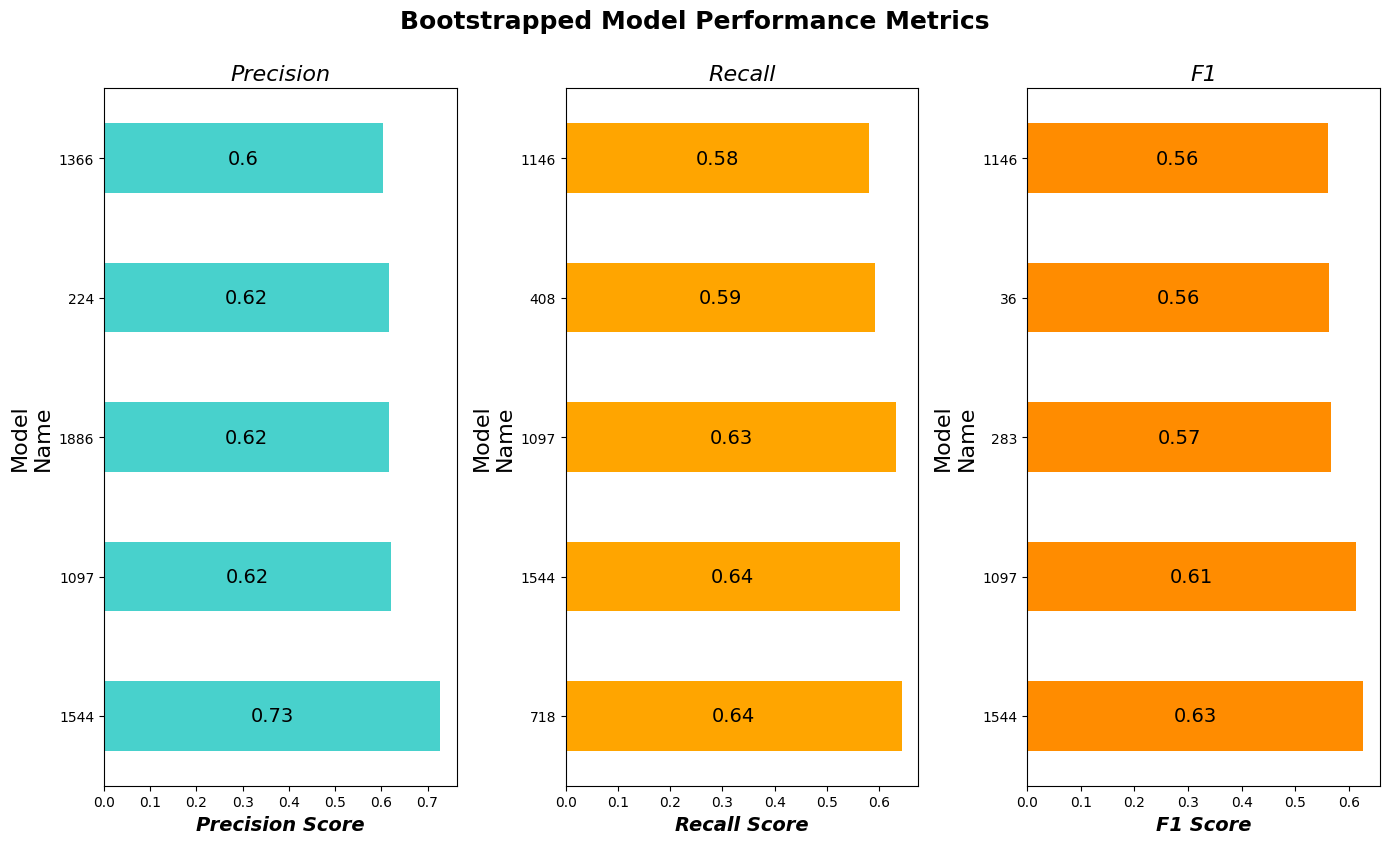

In [13]:
import matplotlib.pyplot as plt

# Create a figure and subplots
fig, (ax2, ax3, ax4) = plt.subplots(1, 3, figsize=(14, 8))

best_of = pred_df.sort_values(by="Precision", ascending=False).head(5)

# Create the first graph
best_of.plot(
    kind="barh",
    x="Model Number",
    y="Precision",
    color="mediumturquoise",
    ax=ax2,
    legend=False,
)
ax2.set_xlabel(
    "Precision Score",
    fontstyle="italic",
    fontsize=14,
    font="Courier New",
    fontweight="bold",
    y=1.1,
)
ylabel = "Model\nName"
ax2.set_ylabel(ylabel, fontsize=16, font="Courier")
ax2.set_title("Precision", fontsize=16, fontstyle="italic")


for index, value in enumerate(best_of["Precision"]):
    ax2.text(
        value / 2,
        index,
        str(round(value, 2)),
        ha="center",
        va="center",
        fontsize=14,
        font="Courier New",
    )
best_of = pred_df.sort_values(by="Recall", ascending=False).head(5)

# Create the second graph
best_of.plot(
    kind="barh",
    x="Model Number",
    y="Recall",
    color="orange",
    ax=ax3,
    legend=False,
)
ax3.set_xlabel(
    "Recall Score",
    fontstyle="italic",
    fontsize=14,
    font="Courier New",
    fontweight="bold",
)
ax3.set_ylabel(ylabel, fontsize=16, font="Courier")
ax3.set_title("Recall", fontsize=16, fontstyle="italic")

for index, value in enumerate(best_of["Recall"]):
    ax3.text(
        value / 2,
        index,
        str(round(value, 2)),
        ha="center",
        va="center",
        fontsize=14,
        font="Courier New",
    )
# Create the third graph
best_of = pred_df.sort_values(by="F1", ascending=False).head(5)
best_of.plot(
    kind="barh",
    x="Model Number",
    y="F1",
    color="darkorange",
    ax=ax4,
    legend=False,
)
ax4.set_xlabel(
    "F1 Score",
    fontstyle="italic",
    fontsize=14,
    font="Courier New",
    fontweight="bold",
)
ax4.set_ylabel(ylabel, fontsize=16, font="Courier")
ax4.set_title("F1", fontsize=16, fontstyle="italic")


for index, value in enumerate(best_of["F1"]):
    ax4.text(
        value / 2,
        index,
        str(round(value, 2)),
        ha="center",
        va="center",
        fontsize=14,
        font="Courier New",
    )
# Fit the figure
plt.tight_layout()

plt.suptitle(
    "Bootstrapped Model Performance Metrics",
    fontsize=18,
    y=1.05,
    fontweight="bold",
    fontname="Courier New",
)

# Show the figure
plt.show()

##Reproducing Best Results


Now, we have already saved the indices to create reproducible results. We will select the 1122th model and see the results whether the results are reproducible or not.

The following code starts by selecting a sample of the data (X and y) using the indices stored in the 1122th row of the pred_df data frame.

The sample data is then split into training and testing datasets using the train_test_split method with a test size of 0.2 and a random state of 42.

Next, a decision tree classifier model is trained using the training data and stored in the model's list. The trained model is then used to make predictions on the test data using the predict() method.

Finally, the precision, recall, and F1 scores of the model are calculated using the precision_score, recall_score, and f1_score functions from the metrics module and printed to the console.

These scores evaluate the model's performance by measuring the model's ability to correctly classify the data and the level of false positives and false negatives generated by the model.

In [7]:
X_sample = X[pred_df.iloc[1544]["Indices_X"], :]
y_sample = y[pred_df.iloc[1544]["Indices_Y"]]

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier().fit(X_train, y_train)
models.append(model)

y_pred = model.predict(X_test)
precision_1122 = metrics.precision_score(y_test, y_pred, average="macro")
recall_1122 = metrics.recall_score(y_test, y_pred, average="macro")
f1_1122 = metrics.f1_score(y_test, y_pred, average="macro")
print("Precision : {}".format(precision_1122))
print("Recall : {}".format(recall_1122))
print("F1 : {}".format(f1_1122))

Precision : 0.6851851851851851
Recall : 0.6527777777777778
F1 : 0.6243386243386243
